In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

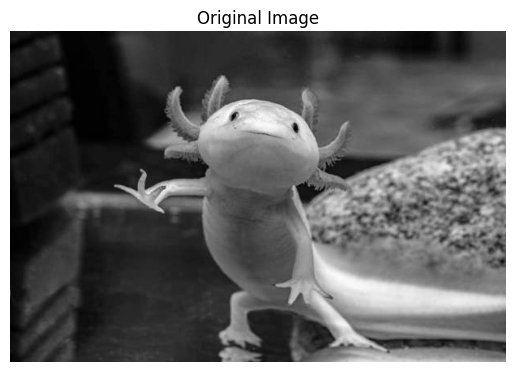

In [4]:
image_path = '../../input.jpg'
image_color = cv2.imread(image_path)
image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

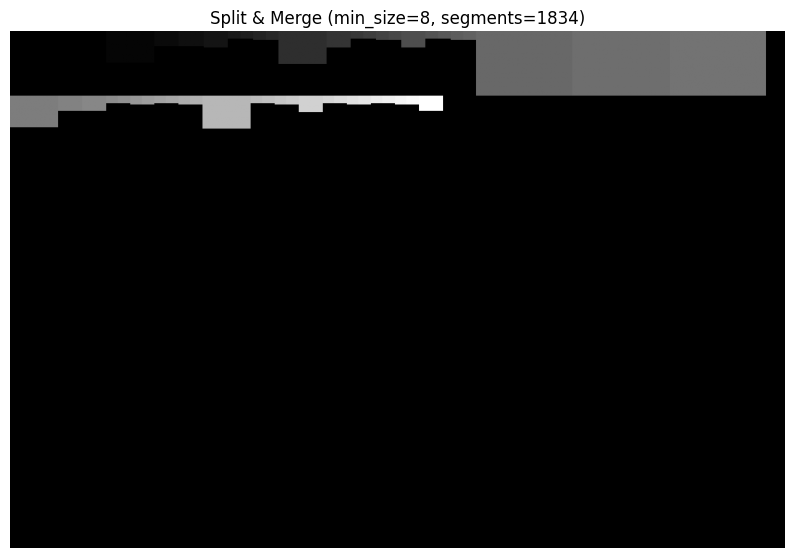

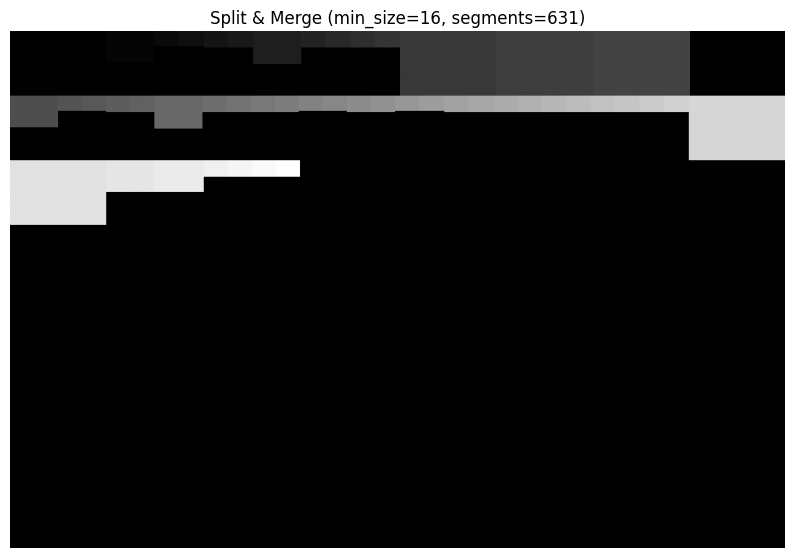

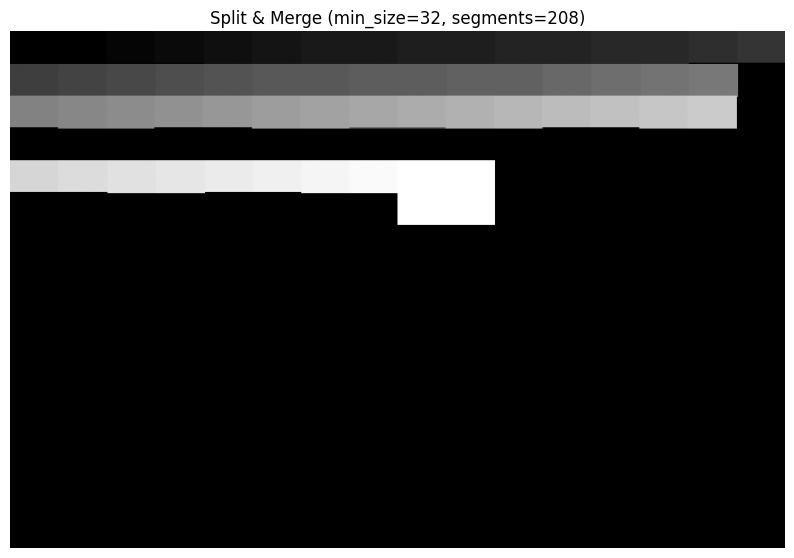

In [5]:
def is_uniform(region, tolerance=10):
    mean_val = np.mean(region)
    std_val = np.std(region)
    return std_val < tolerance

def split_merge(image, min_size=16, max_depth=8):
    def split(region, depth):
        if depth >= max_depth or region.shape[0] < min_size:
            return [region]

        if is_uniform(region):
            return [region]

        h, w = region.shape
        regions = []

        for i in range(2):
            for j in range(2):
                h_start = i * (h // 2)
                h_end = h if i == 1 else h // 2
                w_start = j * (w // 2)
                w_end = w if j == 1 else w // 2

                sub_region = region[h_start:h_end, w_start:w_end]
                regions.extend(split(sub_region, depth + 1))

        return regions

    return split(image, 0)

min_sizes = [8, 16, 32]
results = []

for min_sz in min_sizes:
    segments = split_merge(image, min_size=min_sz)
    results.append(len(segments))

    segmented = np.zeros_like(image)
    row, col = 0, 0

    for idx, seg in enumerate(segments[:50]):
        color = int((idx / min(50, len(segments))) * 255)
        h, w = seg.shape
        if col + w <= image.shape[1]:
            segmented[row:row+h, col:col+w] = color
            col += w
        else:
            row += h
            col = 0

    plt.figure(figsize=(10, 8))
    plt.imshow(segmented, cmap='gray')
    plt.title(f'Split & Merge (min_size={min_sz}, segments={len(segments)})')
    plt.axis('off')
    plt.show()